# 05. Polynomial Terms, Interactions, and Categorical Predictors

A regression model is “linear” when it is linear in the unknown coefficients. It can still contain transformed predictors such as $x^2$, products such as $x_1x_2$, and dummy variables for categories.

By the end of this notebook, you should be able to:

- fit regression models with quadratic terms, interactions, and categorical predictors;
- apply the hierarchy principle when adding higher-order terms;
- interpret interaction slopes and dummy-variable coefficients in context.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


Running outside JupyterLite; assuming packages are already installed.


## Curvature with a Quadratic Term

A quadratic model has the form

$$Y=\beta_0+\beta_1x+\beta_2x^2+\epsilon.$$

The model is linear in $\beta_0,\beta_1,\beta_2$, so ordinary least squares still applies.


                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     528.3
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.31e-08
Time:                        01:54:10   Log-Likelihood:                 4.2726
No. Observations:                  10   AIC:                            -2.545
Df Residuals:                       7   BIC:                            -1.637
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

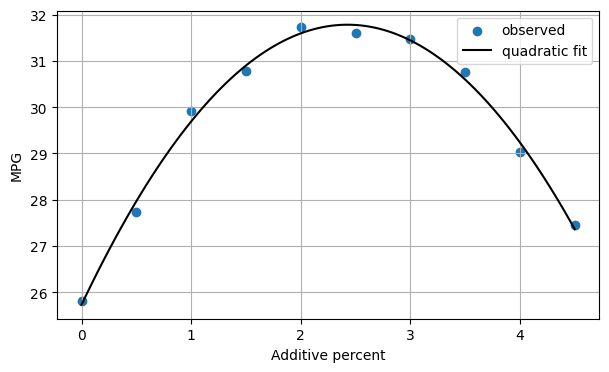

In [2]:
mileage = pd.read_csv("data/mileage_additive.csv")
quad = smf.ols("MPG ~ AdditivePercent + I(AdditivePercent**2)", data=mileage).fit()
print(quad.summary())

x_grid = np.linspace(mileage.AdditivePercent.min(), mileage.AdditivePercent.max(), 100)
pred_grid = pd.DataFrame({"AdditivePercent": x_grid})
plt.scatter(mileage.AdditivePercent, mileage.MPG, label="observed")
plt.plot(x_grid, quad.predict(pred_grid), color="black", label="quadratic fit")
plt.xlabel("Additive percent")
plt.ylabel("MPG")
plt.legend()
plt.show()


## Finding the Best Setting in a Quadratic Model

When the fitted quadratic model is

$$\widehat y=b_0+b_1x+b_2x^2,$$

its vertex occurs at

$$x^*=-\frac{b_1}{2b_2}.$$

If $b_2<0$, this vertex is a maximum of the fitted curve. This calculation should only be interpreted inside a reasonable range of observed or scientifically meaningful $x$ values.


In [3]:
b0, b1, b2 = quad.params["Intercept"], quad.params["AdditivePercent"], quad.params["I(AdditivePercent ** 2)"]
x_star = -b1 / (2 * b2)
y_star = quad.predict(pd.DataFrame({"AdditivePercent": [x_star]}))[0]

print(f"Estimated optimum additive percent: {x_star:.3f}")
print(f"Predicted MPG at the fitted optimum: {y_star:.3f}")
print(f"Observed additive range: {mileage.AdditivePercent.min():.1f} to {mileage.AdditivePercent.max():.1f}")


Estimated optimum additive percent: 2.426
Predicted MPG at the fitted optimum: 31.782
Observed additive range: 0.0 to 4.5


The hierarchy principle says that if a model includes $x^2$, it should usually also include $x$ unless there is a clear scientific reason not to.

## Interaction Terms

An interaction allows the slope of one predictor to depend on another predictor:

$$Y=\beta_0+\beta_1x_1+\beta_2x_2+\beta_{12}x_1x_2+\epsilon.$$


In `statsmodels` formula syntax, `I(AdditivePercent**2)` tells Python to create the squared predictor before fitting the regression model. This is the Python analogue of explicitly creating a new column for the higher-order term.


In [4]:
ads = pd.read_csv("data/advertising_sales.csv")
interaction = smf.ols("Sales ~ RadioSpend * PrintSpend", data=ads).fit()
print(interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     887.8
Date:                Mon, 18 May 2026   Prob (F-statistic):           5.38e-18
Time:                        01:54:10   Log-Likelihood:                -7.3652
No. Observations:                  20   AIC:                             22.73
Df Residuals:                      16   BIC:                             26.71
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.70

In formula syntax, `RadioSpend * PrintSpend` expands to `RadioSpend + PrintSpend + RadioSpend:PrintSpend`. With the interaction included, the effect of radio spending is

$$\frac{\partial E[Y]}{\partial RadioSpend}=\beta_1+\beta_{12}PrintSpend.$$


The hierarchy principle also applies to interactions: if `RadioSpend:PrintSpend` is in the model, the corresponding main effects should usually remain in the model too. The shorthand `RadioSpend * PrintSpend` enforces that convention automatically.


In [5]:
for print_level in [1, 3, 5]:
    radio_slope = interaction.params["RadioSpend"] + interaction.params["RadioSpend:PrintSpend"] * print_level
    print(f"Estimated radio slope when PrintSpend={print_level}: {radio_slope:.3f}")


Estimated radio slope when PrintSpend=1: 2.350
Estimated radio slope when PrintSpend=3: 1.535
Estimated radio slope when PrintSpend=5: 0.721


## Interaction Plot

One practical way to see an interaction is to plot the fitted relationship between one predictor and the response at several fixed values of the other predictor. Nonparallel fitted lines are the visual signal that the slope changes with the second predictor.


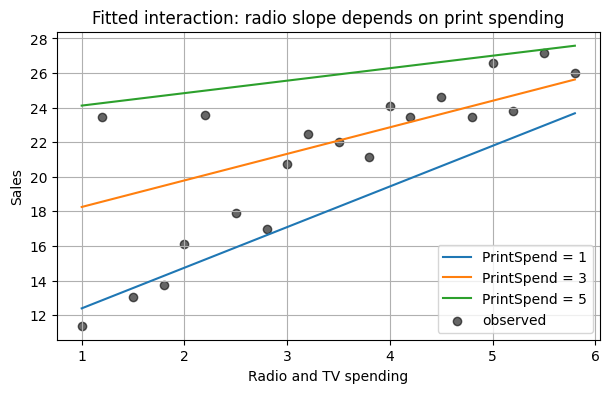

In [6]:
radio_grid = np.linspace(ads.RadioSpend.min(), ads.RadioSpend.max(), 100)
for print_level in [1, 3, 5]:
    grid = pd.DataFrame({"RadioSpend": radio_grid, "PrintSpend": print_level})
    plt.plot(radio_grid, interaction.predict(grid), label=f"PrintSpend = {print_level}")

plt.scatter(ads.RadioSpend, ads.Sales, color="black", alpha=0.6, label="observed")
plt.xlabel("Radio and TV spending")
plt.ylabel("Sales")
plt.title("Fitted interaction: radio slope depends on print spending")
plt.legend()
plt.show()


## Categorical Predictors and Dummy Variables

A categorical variable with $g$ levels is represented with $g-1$ dummy variables when the model has an intercept. The omitted level is the reference category.


Using all $g$ dummy variables together with an intercept would make the design matrix singular. The $g-1$ coding avoids that redundancy and makes every dummy coefficient a comparison against the reference level.


In [7]:
stores = pd.read_csv("data/store_sales.csv")
cat_model = smf.ols('SalesVolume ~ Households + C(Location, Treatment(reference="Street"))', data=stores).fit()
print(cat_model.summary())


                            OLS Regression Results                            
Dep. Variable:            SalesVolume   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     5961.
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.12e-29
Time:                        01:54:10   Log-Likelihood:                -42.386
No. Observations:                  24   AIC:                             92.77
Df Residuals:                      20   BIC:                             97.48
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

Here, `Street` is the reference category. The `Mall` and `Downtown` coefficients estimate differences from the street-store baseline after accounting for the number of households.


In [8]:
new_stores = pd.DataFrame({
    "Households": [120, 120, 120],
    "Location": ["Street", "Mall", "Downtown"],
})
new_stores.assign(PredictedSales=cat_model.predict(new_stores))


,Households,Location,PredictedSales
0,120,Street,116.708517
1,120,Mall,148.325349
2,120,Downtown,137.965327
